# Updates
- 20260920 - V1: 
    - Initial testing of different models and operationability
    - "Make dataset" filters for delivered orders only - Not feasible for actual run because we won't know the actual status on any particular run date
- 20260926 - V2: 
    - Update "Make dataset" to align with actual operations
        - Only pull pXd training data and implement label completeness checks
    - Implement monthly inference backtesting

# Environment Set-up

In [115]:
# Install dependencies (uncomment if running in Colab)
# %pip install -q pandas numpy matplotlib seaborn plotly scikit-learn xgboost catboost lightgbm

import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.ticker import PercentFormatter
from pandas.api.types import is_numeric_dtype

# Machine Learning
import xgboost as xgb
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.impute import SimpleImputer
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, FunctionTransformer, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, roc_auc_score
)

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")

pandas: 2.1.4
numpy: 1.26.4


In [116]:
# === DATA PATH CONFIGURATION ===
# Data is resolved in this order, so a fresh clone needs no manual setup:
#   1. Google Drive, when running in Colab
#   2. Olist_CSV in the project root, if it is already there
#   3. the olist_csv.zip bundled in the repo, extracted on first run
import os
import zipfile

COLAB_DATA_DIR = "/content/drive/MyDrive/NUS/IT5006/Group Project/IT5006_Project-Data/Olist_CSV"
# Support kernels started from either the project root or phase2.
PROJECT_ROOT = os.path.abspath(".." if os.path.basename(os.getcwd()) == "phase2" else ".")
LOCAL_DATA_DIR = os.path.join(PROJECT_ROOT, "Olist_CSV")
BUNDLED_ARCHIVE = os.path.join(PROJECT_ROOT, "streamlit_release", "data", "olist_csv.zip")

try:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = COLAB_DATA_DIR
except ModuleNotFoundError:
    DATA_DIR = LOCAL_DATA_DIR

if not os.path.isdir(DATA_DIR) and os.path.isfile(BUNDLED_ARCHIVE):
    print(f"Extracting {BUNDLED_ARCHIVE} -> {LOCAL_DATA_DIR}")
    with zipfile.ZipFile(BUNDLED_ARCHIVE) as archive:
        archive.extractall(LOCAL_DATA_DIR)
    DATA_DIR = LOCAL_DATA_DIR

# Verify data directory exists (isdir, not exists: a .zip path would pass exists)
if os.path.isdir(DATA_DIR):
    print(f"\u2705 Data directory found: {DATA_DIR}")
    print(f"   Files: {os.listdir(DATA_DIR)}")
else:
    print(f"\u274c Data directory not found: {DATA_DIR}")
    print("   Please update DATA_DIR to point to your Olist data folder")

✅ Data directory found: c:\Users\D00mG\OneDrive\Documents\NUS\github\Team8_IT5006_Ecommerce_Analytics_AY2627Sem1\Olist_CSV
   Files: ['olist_customers_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_orders_dataset.csv', 'olist_order_items_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_products_dataset.csv', 'olist_sellers_dataset.csv', 'product_category_name_translation.csv']


# Load data

In [117]:
# Load all Olist tables
def load_olist_data(data_dir):
    """Load all Olist CSV files into a dictionary of DataFrames."""

    tables = {
        'orders': 'olist_orders_dataset.csv',
        'order_items': 'olist_order_items_dataset.csv',
        'customers': 'olist_customers_dataset.csv',
        'products': 'olist_products_dataset.csv',
        'sellers': 'olist_sellers_dataset.csv',
        'payments': 'olist_order_payments_dataset.csv',
        'reviews': 'olist_order_reviews_dataset.csv',
        'geolocation': 'olist_geolocation_dataset.csv',
        'category_translation': 'product_category_name_translation.csv'
    }

    # Date columns to parse
    date_cols = {
        'orders': ['order_purchase_timestamp', 'order_approved_at',
                   'order_delivered_carrier_date', 'order_delivered_customer_date',
                   'order_estimated_delivery_date'],
        'order_items': ['shipping_limit_date'],
        'reviews': ['review_creation_date', 'review_answer_timestamp']
    }

    data = {}
    for name, filename in tables.items():
        filepath = os.path.join(data_dir, filename)
        parse_dates = date_cols.get(name, None)
        data[name] = pd.read_csv(filepath, parse_dates=parse_dates)
        print(f"Loaded {name}: {data[name].shape[0]:,} rows × {data[name].shape[1]} cols")

    return data

# Load data

olist = load_olist_data(DATA_DIR)

orders = olist['orders']
order_items = olist['order_items']
customers = olist['customers']
products = olist['products']
sellers = olist['sellers']
payments = olist['payments']
reviews = olist['reviews']
geolocation = olist['geolocation']
category_translation = olist['category_translation']

Loaded orders: 99,441 rows × 8 cols
Loaded order_items: 112,650 rows × 7 cols
Loaded customers: 99,441 rows × 5 cols
Loaded products: 32,951 rows × 9 cols
Loaded sellers: 3,095 rows × 4 cols
Loaded payments: 103,886 rows × 5 cols
Loaded reviews: 99,224 rows × 7 cols
Loaded geolocation: 1,000,163 rows × 5 cols
Loaded category_translation: 71 rows × 2 cols


In [118]:
# Translate product catgory names and clean up missing values
count_products_cat_1 = products['product_category_name'].nunique(dropna=False)
count_products_cat_2 = category_translation['product_category_name_english'].nunique(dropna=False)
print(f"products table have {count_products_cat_1} product categories")
print(f"category_translation table have {count_products_cat_2} product categories")

products = products.merge(category_translation, on='product_category_name', how='left')
products["product_category_name"] = (products["product_category_name_english"]
                                    .combine_first(products["product_category_name"])
                                    .fillna("Unknown")
                                    )
products.drop(columns=['product_category_name_english'], inplace=True)

products table have 74 product categories
category_translation table have 71 product categories


# Constants

In [119]:
RANDOM_STATE = 42
LOOKBACK = 45
PXD = 180

ORDER_STATUSES = ['delivered', 'shipped', 'invoiced', 'processing']

In [120]:
# To save in a separate .py file once finalised
NUM_COLS = ['order_approved_day_of_week',
            'order_approved_day_of_month',
            'order_approved_month',
            'order_approved_week_of_year',
            'order_item_count',
            'order_seller_count',
            'order_pdt_price_sum',
            'order_frieght_value_sum',
            'order_revenue_sum',
            'order_product_weight_g_sum',
            'order_product_category_count',
            'seller_dist_km_max',
            'seller_dist_km_min',
            'seller_dist_km_median',
            'seller_dist_km_mean',
            'seller_zip_code_prefix_count',
            'seller_city_count',
            'seller_state_count',
            'payment_value_sum',
            'payment_type_value_boleto',
            'payment_type_value_credit_card',
            'payment_type_value_debit_card',
            'payment_type_value_not_defined',
            'payment_type_value_voucher',
            'payment_type_count_boleto',
            'payment_type_count_credit_card',
            'payment_type_count_debit_card',
            'payment_type_count_not_defined',
            'payment_type_count_voucher',
            ]

CAT_COLS = ['customer_state',
            'route_type'
            ]
FEATURE_COLS = NUM_COLS + CAT_COLS
LABEL_COL = 'dpt_var_late_delivery'

# Helper functions

In [121]:
def get_required_dates(run_date: str, lookback: int = 45, pXd: int = 180):
    """Return (start, end, inference_date) as YYYY-MM-DD strings; window is inclusive."""
    if isinstance(pXd, bool) or not isinstance(pXd, int) or pXd <= 0:
        raise ValueError('pXd must be a positive integer')
    if isinstance(lookback, bool) or not isinstance(lookback, int) or lookback < 0:
        raise ValueError('lookback must be a non-negative integer')

    if not isinstance(run_date, str):
        raise ValueError('run_date must be a YYYY-MM-DD string')
    run_day = pd.to_datetime(run_date, format='%Y-%m-%d', errors='coerce')
    if pd.isna(run_day) or run_day.strftime('%Y-%m-%d') != run_date:
        raise ValueError('run_date must be a valid date in YYYY-MM-DD format')
    inference_date = run_day - pd.Timedelta(days=1)

    train_test_end_date = inference_date - pd.Timedelta(days=lookback)
    train_test_start_date = train_test_end_date - pd.Timedelta(days=pXd-1)

    inference_date_str = inference_date.strftime('%Y-%m-%d')
    train_test_end_date = train_test_end_date.strftime('%Y-%m-%d')
    train_test_start_date = train_test_start_date.strftime('%Y-%m-%d')

    print(f"Train-test period for the inference date of {inference_date_str} with buffer of {lookback} days:")
    print(f"    {train_test_start_date} to {train_test_end_date} ({pXd} days)")

    return train_test_start_date, train_test_end_date, inference_date_str

run_date = '2026-06-02'
train_test_start_date, train_test_end_date, inference_date = get_required_dates(run_date, lookback=LOOKBACK, pXd=PXD)

Train-test period for the inference date of 2026-06-01 with buffer of 45 days:
    2025-10-20 to 2026-04-17 (180 days)


# Feature Engineeering
- Currently only have basic features obtained directly from the tables
- Some additional features ideas:
    - Holiday/busy period indicators
    - Distance between seller and customer (Need to aggregate due to 1 customer to many sellers r/s)
    - Same-state/interstate deliveries indicator

## Orders and Customers
- Filter for selected order statuses only
- Don't need to filter any dates yet - The filtering can be done at model training and model prediction sections for convenience. Otherwise, in model prediction, the entire "Make dataset" flow needs to run again

In [122]:
# Delivered orders
all_orders = orders[orders['order_status'].isin(ORDER_STATUSES)]
all_orders['order_approved_dt'] = all_orders['order_approved_at'].dt.normalize()
all_orders['order_approved_day_of_week'] = (all_orders['order_approved_dt'].dt.dayofweek + 1).astype('Int64')
all_orders['order_approved_day_of_month'] = (all_orders['order_approved_dt'].dt.day).astype('Int64')
all_orders['order_approved_month'] = all_orders['order_approved_dt'].dt.month.astype('Int64')
all_orders['order_approved_week_of_year'] = all_orders['order_approved_dt'].dt.isocalendar().week.clip(upper=52).astype('Int64')
all_orders['partition_yyyymm'] = all_orders['order_approved_at'].dt.to_period('M').astype(str)
all_orders["durn_to_carrier_days"] = (all_orders["order_delivered_carrier_date"] - all_orders["order_approved_at"]).dt.total_seconds()/86400
all_orders["durn_to_customer_days"] = (all_orders["order_delivered_customer_date"] - all_orders["order_approved_at"]).dt.total_seconds()/86400


# Dependent variables
## Classification Binary indicator: 0 - On Time, 1 - Late
all_orders['dpt_var_late_delivery'] = (all_orders['order_delivered_customer_date'].dt.normalize() > all_orders['order_estimated_delivery_date']).astype(int) 
## Regression - To discuss
all_orders["dpt_var_est_vs_delivered_days"] = (all_orders['order_delivered_customer_date'].dt.normalize() - all_orders["order_estimated_delivery_date"]).dt.total_seconds()/86400


# Add customer features
all_orders = all_orders.merge(customers, on='customer_id', how='left')

print(all_orders.shape)
print(f"Unique order_id: {all_orders['order_id'].nunique()}")
display(all_orders[all_orders['dpt_var_late_delivery']==1].head(5))

all_orders['dpt_var_late_delivery'].value_counts()

(98200, 22)
Unique order_id: 98200


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_approved_dt,order_approved_day_of_week,order_approved_day_of_month,order_approved_month,order_approved_week_of_year,partition_yyyymm,durn_to_carrier_days,durn_to_customer_days,dpt_var_late_delivery,dpt_var_est_vs_delivered_days,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
20,203096f03d82e0dffbc41ebc2e2bcfb7,d2b091571da224a1b36412c18bc3bbfe,delivered,2017-09-18 14:31:30,2017-09-19 04:04:09,2017-10-06 17:50:03,2017-10-09 22:23:46,2017-09-28,2017-09-19,2,19,9,38,2017-09,17.57,20.76,1,11.00,d699688533772c15a061e8ce81cb56df,4001,sao paulo,SP
25,fbf9ac61453ac646ce8ad9783d7d0af6,3a874b4d4c4b6543206ff5d89287f0c3,delivered,2018-02-20 23:46:53,2018-02-22 02:30:46,2018-02-26 22:25:22,2018-03-21 22:03:54,2018-03-12,2018-02-22,4,22,2,8,2018-02,4.83,27.81,1,9.00,a25d5f94840d3c6a1a49f271ed83f4ec,21715,rio de janeiro,RJ
41,6ea2f835b4556291ffdc53fa0b3b95e8,c7340080e394356141681bd4c9b8fe31,delivered,2017-11-24 21:27:48,2017-11-25 00:21:09,2017-12-13 21:14:05,2017-12-28 18:59:23,2017-12-21,2017-11-25,6,25,11,47,2017-11,18.87,33.78,1,7.00,3e4fd73f1e86b135b9b121d6abbe9597,19400,presidente venceslau,SP
57,66e4624ae69e7dc89bd50222b59f581f,684fa6da5134b9e4dab731e00011712d,delivered,2018-03-09 14:50:15,2018-03-09 15:40:39,2018-03-15 00:31:19,2018-04-03 13:28:46,2018-04-02,2018-03-09,5,9,3,10,2018-03,5.37,24.91,1,1.00,ddf60e20e6e262e2136801ce5cd628b0,49030,aracaju,SE
58,a685d016c8a26f71a0bb67821070e398,911e4c37f5cafe1604fe6767034bf1ae,delivered,2017-03-13 18:14:36,2017-03-13 18:14:36,2017-03-22 14:03:09,2017-04-06 13:37:16,2017-03-30,2017-03-13,1,13,3,11,2017-03,8.83,23.81,1,7.00,51838d41add414a0b1b989b7d251d9ee,13068,campinas,SP


dpt_var_late_delivery
0    91666
1     6534
Name: count, dtype: int64

## Get inter-state/same-state tagging

In [123]:
all_order_items = order_items.merge(sellers[['seller_id', 'seller_state', 'seller_city']]
                                        , on='seller_id'
                                        , how='left'
                                        )
orders_routes = all_orders.merge(all_order_items,
                                    on='order_id',
                                    how='left'
                                    )
orders_routes.drop(columns=['product_id', 'shipping_limit_date'], inplace=True)
orders_routes = orders_routes.sort_values(['order_id', 'seller_id'])

orders_routes['item_is_interstate'] = orders_routes['customer_state'] != orders_routes['seller_state']

groupby_cols = ['order_id', 'customer_state']
orders_routes_states = orders_routes.groupby(groupby_cols).agg(
                                    seller_count=('seller_id', 'nunique'),
                                    seller_state_count=('seller_state', 'nunique'),
                                    interstate_item_count=('item_is_interstate', 'sum'),
                                    item_count=('order_item_id', 'count'),
                                    all_interstate=('item_is_interstate', 'all'),
                                    any_interstate=('item_is_interstate', 'any')
                                ).reset_index()
orders_routes_states['route_type'] = np.select([orders_routes_states['all_interstate'], ~orders_routes_states['any_interstate']],
                                                ['1. All interstate', '2. All same-state'],
                                               default='3. Mixed'
                                               )
print(f"Unique orders: {orders_routes_states['order_id'].nunique()}")
print(f"Shape: {orders_routes_states.shape}")
display(orders_routes_states.head())
orders_routes_states['route_type'].value_counts()

Unique orders: 98200
Shape: (98200, 9)


,order_id,customer_state,seller_count,seller_state_count,interstate_item_count,item_count,all_interstate,any_interstate,route_type
0,00010242fe8c5a6d1ba2dd792cb16214,RJ,1,1,1,1,True,True,1. All interstate
1,00018f77f2f0320c557190d7a144bdd3,SP,1,1,0,1,False,False,2. All same-state
2,000229ec398224ef6ca0657da4fc703e,MG,1,1,0,1,False,False,2. All same-state
3,00024acbcdf0a6daa1e931b038114c75,SP,1,1,0,1,False,False,2. All same-state
4,00042b26cf59d7ce69dfabb4e55b4fd9,SP,1,1,1,1,True,True,1. All interstate


route_type
1. All interstate    62846
2. All same-state    35107
3. Mixed               247
Name: count, dtype: int64

## Seller-customer distance

In [124]:
geo_by_zip = (
    geolocation
    .groupby('geolocation_zip_code_prefix', as_index=False)
    .agg(
        latitude=('geolocation_lat', 'median'),
        longitude=('geolocation_lng', 'median')
    )
)

customer_coordinates = (
    customers[['customer_id', 'customer_zip_code_prefix']]
    .merge(
        geo_by_zip.rename(columns={
            'geolocation_zip_code_prefix': 'customer_zip_code_prefix',
            'latitude': 'customer_latitude',
            'longitude': 'customer_longitude'
        }),
        on='customer_zip_code_prefix',
        how='left'
    )
)

seller_coordinates = (
    sellers[['seller_id', 'seller_zip_code_prefix']]
    .merge(
        geo_by_zip.rename(columns={
            'geolocation_zip_code_prefix': 'seller_zip_code_prefix',
            'latitude': 'seller_latitude',
            'longitude': 'seller_longitude'
        }),
        on='seller_zip_code_prefix',
        how='left'
    )
)

# One row per order-seller
distance_order_seller = (
    order_items[['order_id', 'seller_id']]
    .drop_duplicates()
    .merge(seller_coordinates, on='seller_id', how='left')
    .merge(
        orders[['order_id', 'customer_id']],
        on='order_id',
        how='left'
    )
    .merge(customer_coordinates, on='customer_id', how='left')
)

def haversine_km(lat1, lon1, lat2, lon2):
    """Vectorised great-circle distance in kilometres."""
    earth_radius_km = 6371.0088
    lat1_rad, lon1_rad = np.radians(lat1), np.radians(lon1)
    lat2_rad, lon2_rad = np.radians(lat2), np.radians(lon2)
    delta_lat = lat2_rad - lat1_rad
    delta_lon = lon2_rad - lon1_rad
    a = (
        np.sin(delta_lat / 2) ** 2
        + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(delta_lon / 2) ** 2
    )
    return 2 * earth_radius_km * np.arcsin(np.sqrt(a))

distance_order_seller['distance_km'] = haversine_km(
    distance_order_seller['seller_latitude'],
    distance_order_seller['seller_longitude'],
    distance_order_seller['customer_latitude'],
    distance_order_seller['customer_longitude']
)

distance_by_order = (
    distance_order_seller
    .groupby('order_id', as_index=False)
    .agg(
        seller_dist_km_max=('distance_km', 'max'),
        seller_dist_km_min=('distance_km', 'min'),
        seller_dist_km_median=('distance_km', 'median'),
        seller_dist_km_mean=('distance_km', 'mean'),
        seller_dist_km_count=('seller_id', 'nunique')
    )
)

distance_delivery = all_orders[['order_id']].merge(distance_by_order, on='order_id', how='left')

coordinate_coverage = distance_delivery['seller_dist_km_max'].notna().mean()
print(f"Delivered orders with usable distance: {coordinate_coverage:.1%}")
print(f"Unique orders: {distance_delivery['order_id'].nunique()}")
print(f"Shape: {distance_delivery.shape}")

display(distance_delivery[distance_delivery['seller_dist_km_count']>2].head())
display(distance_delivery['seller_dist_km_count'].value_counts(dropna=False))

Delivered orders with usable distance: 99.5%
Unique orders: 98200
Shape: (98200, 6)


,order_id,seller_dist_km_max,seller_dist_km_min,seller_dist_km_median,seller_dist_km_mean,seller_dist_km_count
602,a98012aa8c697f2bcff9f8c2183e0f2b,498.90,387.18,482.65,456.24,3.00
3536,780dfcd5aaf2662f3f6ce2201164394b,852.93,134.09,513.68,500.23,3.00
3801,bb44d0c37f5fcc456bbaefd9aef6adb8,525.84,202.23,363.87,363.98,3.00
3909,179e23361d372901e40a92f8c29bd61d,834.03,808.78,828.65,823.82,3.00
5183,d839ea07a528e914f89702508023da37,451.78,334.73,337.56,374.69,3.00


seller_dist_km_count
1.00    96920
2.00     1218
3.00       54
4.00        3
NaN         3
5.00        2
Name: count, dtype: int64

## Aggregate order items

In [125]:
all_order_items = order_items.copy()
all_order_items = all_order_items.merge(products[['product_id', 'product_category_name', 'product_photos_qty', 'product_weight_g']]
                                    , on='product_id'
                                    , how='left'
                                    )
all_order_items = all_order_items.merge(sellers, on='seller_id', how='left')
all_order_items['item_revenue'] = all_order_items['price'] + all_order_items['freight_value']
all_order_items = all_order_items.sort_values(['order_id', 'order_item_id'])
print(all_order_items.shape)
print(f"Unique order_id: {all_order_items['order_id'].nunique()}")

(112650, 14)
Unique order_id: 98666


In [126]:
order_items_agg = all_order_items.groupby('order_id').agg(
    order_item_count=('product_id', 'count'),
    order_seller_count=('seller_id', 'nunique'),
    order_pdt_price_sum=('price', 'sum'),
    order_frieght_value_sum=('freight_value', 'sum'),
    order_revenue_sum=('item_revenue', 'sum'),
    order_product_weight_g_sum=('product_weight_g', 'sum'),
    order_product_category_count=('product_category_name', 'nunique'),
    seller_zip_code_prefix_count=('seller_zip_code_prefix', 'nunique'),
    seller_city_count=('seller_city', 'nunique'),
    seller_state_count=('seller_state', 'nunique'),

    product_category_name=('product_category_name', set),
    seller_zip_code_prefix=('seller_zip_code_prefix', set),
    seller_city=('seller_city', set),
    seller_state=('seller_state', set),
).reset_index()

print(f"Shape: {order_items_agg.shape}")
print(f"Unique order_id: {order_items_agg['order_id'].nunique()}")
cond = (order_items_agg['order_item_count'] > 2) | (order_items_agg['order_seller_count'] > 1)
display(order_items_agg[cond].head())

# Sample order with >1 item
# display(all_order_items[all_order_items['order_id'] == 'fffb9224b6fc7c43ebb0904318b10b5f']) 

Shape: (98666, 15)
Unique order_id: 98666


,order_id,order_item_count,order_seller_count,order_pdt_price_sum,order_frieght_value_sum,order_revenue_sum,order_product_weight_g_sum,order_product_category_count,seller_zip_code_prefix_count,seller_city_count,seller_state_count,product_category_name,seller_zip_code_prefix,seller_city,seller_state
31,00143d0f86d6fbd9f9b38ab440ac16f5,3,1,63.99,45.30,109.29,540.00,1,1,1,1,{sports_leisure},{18055},{sorocaba},{SP}
39,001ab0a7578dd66cd4b0a71f5b6e1e41,3,1,74.67,52.89,127.56,450.00,1,1,1,1,{electronics},{72015},{brasilia},{DF}
73,002f98c0f7efd42638ed6100ca699b42,2,2,53.89,39.73,93.62,650.00,2,2,2,2,"{consoles_games, toys}","{38440, 2310}","{sao paulo, araguari}","{MG, SP}"
124,00526a9d4ebde463baee25f386963ddc,4,1,135.56,33.60,169.16,1552.00,1,1,1,1,{food},{3279},{sao paulo},{SP}
134,005d9a5423d47281ac463a968b3936fb,3,1,99.97,45.28,145.25,350.00,2,1,1,1,"{baby, toys}",{90010},{porto alegre},{RS}


## Aggregate payments

In [127]:
payment_type_agg = payments.pivot_table(
    index='order_id',
    columns='payment_type',
    values='payment_value',
    aggfunc=['sum', 'size'],
    fill_value=0,
)

payment_type_agg.columns = [
    f"payment_type_{'count' if agg == 'size' else 'value'}_{ptype}"
    for agg, ptype in payment_type_agg.columns
]

# Note: Current code does not guard against new payment types in future
payments_agg = (
    payments.groupby('order_id')
    .agg(payment_value_sum=('payment_value', 'sum'))
    .join(payment_type_agg)
    .reset_index()
)
print(f"Shape: {payments_agg.shape}")
print(f"Unique order_id: {payments_agg['order_id'].nunique()}")

# Check samples
samples = ['0016dfedd97fc2950e388d2971d718c7', '009ac365164f8e06f59d18a08045f6c4', 'fee9afa24ed743a26803c4d03e8ba5e1']
display(payments_agg[payments_agg['order_id'].isin(samples)])
display(payments[payments['order_id'].isin(samples)].sort_values(['order_id', 'payment_sequential']))

Shape: (99440, 12)
Unique order_id: 99440


,order_id,payment_value_sum,payment_type_value_boleto,payment_type_value_credit_card,payment_type_value_debit_card,payment_type_value_not_defined,payment_type_value_voucher,payment_type_count_boleto,payment_type_count_credit_card,payment_type_count_debit_card,payment_type_count_not_defined,payment_type_count_voucher
36,0016dfedd97fc2950e388d2971d718c7,70.55,0.00,52.63,0.00,0.00,17.92,0,1,0,0,1
215,009ac365164f8e06f59d18a08045f6c4,32.00,0.00,0.88,0.00,0.00,31.12,0,1,0,0,5
99040,fee9afa24ed743a26803c4d03e8ba5e1,61.78,0.00,61.78,0.00,0.00,0.00,0,2,0,0,0


,order_id,payment_sequential,payment_type,payment_installments,payment_value
89575,0016dfedd97fc2950e388d2971d718c7,1,credit_card,5,52.63
80856,0016dfedd97fc2950e388d2971d718c7,2,voucher,1,17.92
16053,009ac365164f8e06f59d18a08045f6c4,1,credit_card,1,0.88
16459,009ac365164f8e06f59d18a08045f6c4,2,voucher,1,4.50
73837,009ac365164f8e06f59d18a08045f6c4,3,voucher,1,8.25
32058,009ac365164f8e06f59d18a08045f6c4,4,voucher,1,5.45
285,009ac365164f8e06f59d18a08045f6c4,5,voucher,1,8.75
15298,009ac365164f8e06f59d18a08045f6c4,6,voucher,1,4.17
41032,fee9afa24ed743a26803c4d03e8ba5e1,1,credit_card,3,37.89
87715,fee9afa24ed743a26803c4d03e8ba5e1,2,credit_card,2,23.89


# Make dataset
- Final dataframe containing all features, the partition month and the dependent variables
- Features to be expanded with further engineering

In [128]:
final_df = all_orders.merge(orders_routes_states[['order_id', 'route_type']], on='order_id', how='left'
                    ).merge(distance_delivery, on='order_id', how='left'
                    ).merge(order_items_agg, on='order_id', how='left'
                    ).merge(payments_agg, on='order_id', how='left'
                    )

print(f"Shape: {final_df.shape}")
print(f"Unique order_id: {final_df['order_id'].nunique()}")

print("\nAfter filtering for orders >= 2017-01...")
final_df = final_df[final_df['partition_yyyymm'] >= '2017-01']
print(f"Shape: {final_df.shape}")
print(f"Unique order_id: {final_df['order_id'].nunique()}")

null_counts = final_df.isna().sum()
display(null_counts[null_counts > 0].sort_values(ascending=False))

print(f"Shape: {final_df.shape}")
print(f"Unique order_id: {final_df['order_id'].nunique()}")
print(final_df.shape)

display(final_df.head())

Shape: (98200, 53)
Unique order_id: 98200

After filtering for orders >= 2017-01...
Shape: (97904, 53)
Unique order_id: 97904


durn_to_customer_days            1715
order_delivered_customer_date    1701
dpt_var_est_vs_delivered_days    1701
durn_to_carrier_days              611
order_delivered_carrier_date      597
seller_dist_km_max                487
seller_dist_km_min                487
seller_dist_km_median             487
seller_dist_km_mean               487
order_approved_at                  14
order_approved_dt                  14
order_approved_day_of_week         14
order_approved_day_of_month        14
order_approved_month               14
order_approved_week_of_year        14
dtype: int64

Shape: (97904, 53)
Unique order_id: 97904
(97904, 53)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_approved_dt,order_approved_day_of_week,order_approved_day_of_month,order_approved_month,order_approved_week_of_year,partition_yyyymm,durn_to_carrier_days,durn_to_customer_days,dpt_var_late_delivery,dpt_var_est_vs_delivered_days,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,route_type,seller_dist_km_max,seller_dist_km_min,...,order_item_count,order_seller_count,order_pdt_price_sum,order_frieght_value_sum,order_revenue_sum,order_product_weight_g_sum,order_product_category_count,seller_zip_code_prefix_count,seller_city_count,seller_state_count,product_category_name,seller_zip_code_prefix,seller_city,seller_state,payment_value_sum,payment_type_value_boleto,payment_type_value_credit_card,payment_type_value_debit_card,payment_type_value_not_defined,payment_type_value_voucher,payment_type_count_boleto,payment_type_count_credit_card,payment_type_count_debit_card,payment_type_count_not_defined,payment_type_count_voucher
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10-02,1,2,10,40,2017-10,2.37,8.43,0,-8.00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2. All same-state,18.68,18.68,...,1.00,1.00,29.99,8.72,38.71,500.00,1.00,1.00,1.00,1.00,{housewares},{9350},{maua},{SP},38.71,0.00,18.12,0.00,0.00,20.59,0.00,1.00,0.00,0.00,2.00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07-26,4,26,7,30,2018-07,0.46,12.50,0,-6.00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1. All interstate,861.04,861.04,...,1.00,1.00,118.70,22.76,141.46,400.00,1.00,1.00,1.00,1.00,{perfumery},{31570},{belo horizonte},{SP},141.46,141.46,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08-08,3,8,8,32,2018-08,0.20,9.38,0,-18.00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1. All interstate,514.55,514.55,...,1.00,1.00,159.90,19.22,179.12,420.00,1.00,1.00,1.00,1.00,{auto},{14840},{guariba},{SP},179.12,0.00,179.12,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11-18,6,18,11,46,2017-11,3.75,13.20,0,-13.00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1. All interstate,1821.81,1821.81,...,1.00,1.00,45.00,27.20,72.20,450.00,1.00,1.00,1.00,1.00,{pet_shop},{31842},{belo horizonte},{MG},72.20,0.00,72.20,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018-02-13,2,13,2,7,2018-02,0.89,2.83,0,-10.00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,2. All same-state,29.59,29.59,...,1.00,1.00,19.90,8.72,28.62,250.00,1.00,1.00,1.00,1.00,{stationery},{8752},{mogi das cruzes},{SP},28.62,0.00,28.62,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00


# Sanity checks

## Daily aggregation

,order_approved_dt,orders,order_revenue_sum,late_rate
597,2018-09-03,1,166.46,0.00
596,2018-08-29,15,2298.71,0.00
595,2018-08-28,56,5738.28,0.00
594,2018-08-27,64,6447.78,0.00
593,2018-08-26,70,11508.11,0.00
...,...,...,...,...
4,2017-01-09,4,863.31,25.00
3,2017-01-08,4,527.74,0.00
2,2017-01-07,33,2019.30,3.03
1,2017-01-06,3,966.83,0.00


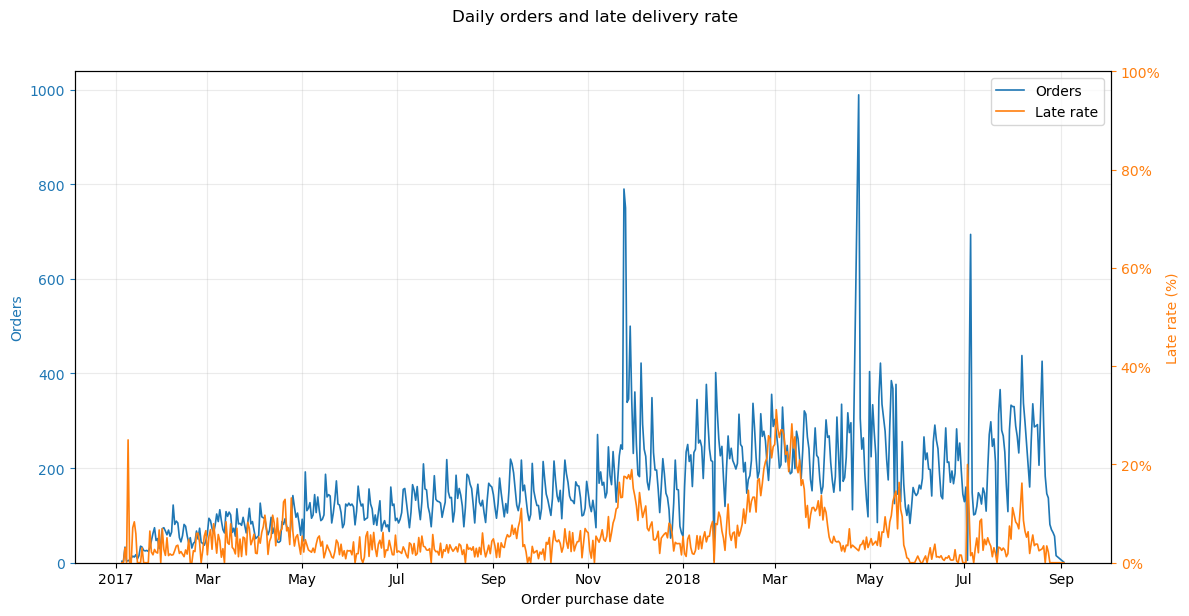

In [129]:
groupby_cols = ['order_approved_dt']
grouped = final_df.groupby(groupby_cols).agg(
    orders = ('order_id', 'nunique'),
    order_revenue_sum = ('order_revenue_sum', 'sum'),
    late_rate = ('dpt_var_late_delivery', 'mean')
).reset_index().sort_values('order_approved_dt', ascending=False)
grouped['late_rate'] = (grouped['late_rate']*100).round(2)
display(grouped)

# Share the purchase-date x-axis, with independent left/right y-axes.
plot_df = grouped.sort_values('order_approved_dt')
fig, ax_orders = plt.subplots(figsize=(12, 6))
ax_late = ax_orders.twinx()

orders_line, = ax_orders.plot(plot_df['order_approved_dt'], plot_df['orders'],
                              color='tab:blue', label='Orders', linewidth=1.2)
late_line, = ax_late.plot(plot_df['order_approved_dt'], plot_df['late_rate'],
                          color='tab:orange', label='Late rate', linewidth=1.2)

ax_orders.set_xlabel('Order purchase date')
ax_orders.set_ylabel('Orders', color='tab:blue')
ax_orders.tick_params(axis='y', colors='tab:blue')
ax_orders.set_ylim(bottom=0)
ax_late.set_ylabel('Late rate (%)', color='tab:orange')
ax_late.tick_params(axis='y', colors='tab:orange')
ax_late.set_ylim(0, 100)
ax_late.yaxis.set_major_formatter(PercentFormatter(xmax=100))
date_locator = mdates.AutoDateLocator()
ax_orders.xaxis.set_major_locator(date_locator)
ax_orders.xaxis.set_major_formatter(mdates.ConciseDateFormatter(date_locator))
ax_orders.grid(alpha=0.25)
ax_orders.legend(handles=[orders_line, late_line], loc='best')
fig.suptitle('Daily orders and late delivery rate', y=1.02)
fig.tight_layout()
plt.show()

## Check buffer period
- To make sure that all labels are available after this buffer period

### Check buffer lengths at each run date
- Review label availability at historical run times.
- Same population as final_df (eventually delivered orders), one row per order.
- This does not measure completeness for all approved/cancelled orders.
- Assumes delivery events are recorded immediately; estimated dates are fixed.

**Unknown labels have two subcategories:**

1. `unresolved`: the order is still undelivered as of the run timestamp, and its estimated delivery day has not fully passed.
2. `invalid_or_missing_dates`: required dates are missing or inconsistent, so a reliable label cannot be assigned. These orders are counted in `invalid_dates`.

Both subcategories retain a missing `label_as_of_run`: **unknown_labels = unresolved orders + invalid_dates**.

For example, suppose the model runs on **August 1, 2018 at 00:30**:

| Approval date | Estimated delivery date | Actual delivery date in the dataset | Subcategory | Why the label is unknown at the run time |
|---|---|---|---|---|
| July 1, 2018 | August 5, 2018 | August 3, 2018 | `unresolved` | Delivery is still in the future at the run time, and the deadline has not passed. |
| July 1, 2018 | August 1, 2018 | Missing | `unresolved` | The order still has the remainder of August 1 to arrive on time. |
| July 1, 2018 | Missing | July 20, 2018 | `invalid_or_missing_dates` | The order was delivered, but its estimated date is missing, so lateness cannot be determined. |
| July 5, 2018 | July 20, 2018 | July 3, 2018 | `invalid_or_missing_dates` | Delivery appears to precede approval, indicating inconsistent dates. |

The first two examples are unresolved; the last two have invalid or missing dates. All four count toward `unknown_labels`, but only the last two count toward `invalid_dates`.

By comparison, an order estimated for **July 31, 2018** that is still undelivered at this run time has a **known label of 1 (late)**, assuming its required dates are valid: its promised delivery day has fully passed. A missing actual delivery date alone does not make an order invalid.

In [130]:
BUFFER_RUN_DATES = ['2018-06-01', '2018-07-01', '2018-08-01']
BUFFER_DAYS = [15, 30, 45, 60, 75, 90]
BUFFER_WINDOW_DAYS = PXD
BUFFER_COMPLETENESS_TARGET = 99.0  # To set an acceptable threshold

label_orders = orders.loc[
        orders['order_id'].isin(final_df['order_id']),
        ['order_id', 'order_approved_at', 'order_delivered_customer_date', 'order_estimated_delivery_date']
    ].drop_duplicates('order_id').copy()
for col in label_orders.columns.drop('order_id'):
    label_orders[col] = pd.to_datetime(label_orders[col])
label_orders['order_approved_dt'] = label_orders['order_approved_at'].dt.normalize()


def labels_as_of(order_rows, run_date: str):
    """Assign labels as of 00:30 on run_date, supplied as a YYYY-MM-DD string."""
    if not isinstance(run_date, str):
        raise ValueError('run_date must be a YYYY-MM-DD string')
    run_day = pd.to_datetime(run_date, format='%Y-%m-%d', errors='coerce')
    if pd.isna(run_day) or run_day.strftime('%Y-%m-%d') != run_date:
        raise ValueError('run_date must be a valid date in YYYY-MM-DD format')
    run_timestamp = run_day + pd.Timedelta(minutes=30)
    result = order_rows.copy()
    approved = result['order_approved_at']
    delivered = result['order_delivered_customer_date']
    # An estimated date remains on time until the following midnight.
    deadline = result['order_estimated_delivery_date'].dt.normalize() + pd.Timedelta(days=1)
    valid = approved.notna() & approved.le(run_timestamp) & deadline.notna()
    # Flag impossible delivery timestamps instead of assigning their labels.
    invalid_delivery = delivered.notna() & delivered.lt(approved)
    valid &= ~invalid_delivery
    delivered_by_run = delivered.notna() & delivered.le(run_timestamp)
    overdue = deadline.le(run_timestamp)

    result['delivered_by_run'] = delivered_by_run
    result['label_as_of_run'] = pd.Series(pd.NA, index=result.index, dtype='Int64')
    result['label_status'] = 'unresolved'
    result.loc[~valid, 'label_status'] = 'invalid_or_missing_dates'
    on_time = valid & delivered_by_run & delivered.lt(deadline)
    late_delivered = valid & delivered_by_run & delivered.ge(deadline)
    late_undelivered = valid & ~delivered_by_run & overdue
    result.loc[on_time, 'label_as_of_run'] = 0
    result.loc[late_delivered | late_undelivered, 'label_as_of_run'] = 1
    result.loc[on_time, 'label_status'] = 'on_time_delivered'
    result.loc[late_delivered, 'label_status'] = 'late_delivered'
    result.loc[late_undelivered, 'label_status'] = 'late_undelivered' # Run date already exceeded estimated delivery date and not delivered yet
    return result


buffer_rows = []
buffer_label_audits = {}  # Inspect an individual run/buffer's order-level labels.
for run_date in BUFFER_RUN_DATES:
    run_timestamp = pd.Timestamp(run_date) + pd.Timedelta(minutes=30)
    inference_date = run_timestamp.normalize() - pd.Timedelta(days=1)
    as_of = labels_as_of(label_orders, run_date=run_date)
    for buffer_days in BUFFER_DAYS:
        end_date = inference_date - pd.Timedelta(days=buffer_days)
        start_date = end_date - pd.Timedelta(days=BUFFER_WINDOW_DAYS - 1)
        window = as_of.loc[
            as_of['order_approved_dt'].between(start_date, end_date)
        ].copy()
        buffer_label_audits[(run_date, buffer_days)] = window
        for scope, scope_start in [
            ('full_window', start_date),
            ('newest_7_days', max(start_date, end_date - pd.Timedelta(days=6)))
        ]:
            cohort = window.loc[window['order_approved_dt'].ge(scope_start)]
            total = len(cohort)
            known = int(cohort['label_as_of_run'].notna().sum())
            completeness = 100 * known / total if total else float('nan')
            buffer_rows.append({
                'run_timestamp': run_timestamp, 'buffer_days': buffer_days,
                'scope': scope, 'start_date': scope_start, 'end_date': end_date,
                'orders': total, 'known_labels': known,
                'unknown_labels': total - known,
                'on_time_delivered': int(cohort['label_status'].eq('on_time_delivered').sum()),
                'late_delivered': int(cohort['label_status'].eq('late_delivered').sum()),
                'late_undelivered': int(cohort['label_status'].eq('late_undelivered').sum()),
                'total_late_delivery_rate_pct': 100 * cohort['label_as_of_run'].eq(1).sum() / known if known else float('nan'),
                # 'invalid_dates': int(cohort['label_status'].eq('invalid_or_missing_dates').sum()),
                'delivered_by_run_pct': 100 * cohort['delivered_by_run'].sum() / total if total else float('nan'),
                'label_completeness_pct': completeness,
                'meets_target': bool(total and completeness >= BUFFER_COMPLETENESS_TARGET)
            })

buffer_review = pd.DataFrame(buffer_rows)
print('Completeness within the existing eventually-delivered modelling population.')
print('Unknown labels include invalid/missing dates; these must be excluded from training.')
for scope in ['full_window', 'newest_7_days']:
    print(f'\n{scope}:')
    display(buffer_review.loc[buffer_review['scope'].eq(scope)].round(2))

buffer_summary = buffer_review.groupby('buffer_days', as_index=False).agg(
    worst_completeness_pct=('label_completeness_pct', 'min'),
    all_runs_and_scopes_meet_target=('meets_target', 'all')
)
display(buffer_summary.round(2))
passing_buffers = buffer_summary.loc[
    buffer_summary['all_runs_and_scopes_meet_target'], 'buffer_days'
]
if passing_buffers.empty:
    print(f'No candidate meets {BUFFER_COMPLETENESS_TARGET}% in every run and scope.')
else:
    print(f'Smallest candidate meeting {BUFFER_COMPLETENESS_TARGET}% in every run and scope: '
          f'{passing_buffers.min()} days. This is historical evidence, not a future guarantee.')
# For a real run, train only on audit rows where label_as_of_run.notna().

Completeness within the existing eventually-delivered modelling population.
Unknown labels include invalid/missing dates; these must be excluded from training.

full_window:


,run_timestamp,buffer_days,scope,start_date,end_date,orders,known_labels,unknown_labels,on_time_delivered,late_delivered,late_undelivered,total_late_delivery_rate_pct,delivered_by_run_pct,label_completeness_pct,meets_target
0,2018-06-01 00:30:00,15,full_window,2017-11-18,2018-05-16,42687,42152,535,37218,4083,851,11.71,96.79,98.75,False
2,2018-06-01 00:30:00,30,full_window,2017-11-03,2018-05-01,40916,40873,43,35902,4186,785,12.16,98.02,99.89,True
4,2018-06-01 00:30:00,45,full_window,2017-10-19,2018-04-16,39387,39384,3,34457,4206,721,12.51,98.17,99.99,True
6,2018-06-01 00:30:00,60,full_window,2017-10-04,2018-04-01,38275,38273,2,33460,4143,670,12.58,98.25,99.99,True
8,2018-06-01 00:30:00,75,full_window,2017-09-19,2018-03-17,37074,37072,2,32606,3826,640,12.05,98.27,99.99,True
10,2018-06-01 00:30:00,90,full_window,2017-09-04,2018-03-02,35758,35748,10,32056,3116,576,10.33,98.39,99.97,True
12,2018-07-01 00:30:00,15,full_window,2017-12-18,2018-06-15,39754,39559,195,35449,3481,629,10.39,97.97,99.51,True
14,2018-07-01 00:30:00,30,full_window,2017-12-03,2018-05-31,39916,39889,27,35465,3750,674,11.09,98.29,99.93,True
16,2018-07-01 00:30:00,45,full_window,2017-11-18,2018-05-16,42687,42670,17,37522,4406,742,12.06,98.26,99.96,True
18,2018-07-01 00:30:00,60,full_window,2017-11-03,2018-05-01,40916,40899,17,35910,4269,720,12.20,98.24,99.96,True



newest_7_days:


,run_timestamp,buffer_days,scope,start_date,end_date,orders,known_labels,unknown_labels,on_time_delivered,late_delivered,late_undelivered,total_late_delivery_rate_pct,delivered_by_run_pct,label_completeness_pct,meets_target
1,2018-06-01 00:30:00,15,newest_7_days,2018-05-10,2018-05-16,2019,1626,393,1567,10,49,3.63,78.11,80.53,False
3,2018-06-01 00:30:00,30,newest_7_days,2018-04-25,2018-05-01,1629,1608,21,1538,27,43,4.35,96.07,98.71,False
5,2018-06-01 00:30:00,45,newest_7_days,2018-04-10,2018-04-16,1599,1598,1,1517,40,41,5.07,97.37,99.94,True
7,2018-06-01 00:30:00,60,newest_7_days,2018-03-26,2018-04-01,1440,1440,0,1248,158,34,13.33,97.64,100.00,True
9,2018-06-01 00:30:00,75,newest_7_days,2018-03-11,2018-03-17,1595,1595,0,1192,356,47,25.27,97.05,100.00,True
11,2018-06-01 00:30:00,90,newest_7_days,2018-02-24,2018-03-02,1838,1838,0,1361,450,27,25.95,98.53,100.00,True
13,2018-07-01 00:30:00,15,newest_7_days,2018-06-09,2018-06-15,1573,1461,112,1442,7,12,1.30,92.12,92.88,False
15,2018-07-01 00:30:00,30,newest_7_days,2018-05-25,2018-05-31,872,864,8,861,0,3,0.35,98.74,99.08,True
17,2018-07-01 00:30:00,45,newest_7_days,2018-05-10,2018-05-16,2019,2019,0,1817,172,30,10.00,98.51,100.00,True
19,2018-07-01 00:30:00,60,newest_7_days,2018-04-25,2018-05-01,1629,1629,0,1544,63,22,5.22,98.65,100.00,True


,buffer_days,worst_completeness_pct,all_runs_and_scopes_meet_target
0,15,80.53,False
1,30,98.71,False
2,45,99.94,True
3,60,99.96,True
4,75,99.96,True
5,90,99.96,True


Smallest candidate meeting 99.0% in every run and scope: 45 days. This is historical evidence, not a future guarantee.


# Get training data
- To operationalise this, I am thinking we need to run predictions on a daily basis, for example:
    - The prediction job is set to run at 0030 daily
    - At 2018-08-01 0030H, the orders approved on 2018-07-31 would have all came in. We want to predict whether the orders approved on 2018-07-31 will be late.
    - To do so, we look at the last delivered orders from 30 days ago (end_date) to past X days ago (start_date)
        - Run date: 2018-08-01
        - Inference date: 2018-07-31 (we are predicting for orders approved on this date)
        - Train-test period: 2018-01-03 to 2018-07-01 based on lookback period of 30 days and pXd of 180 days
    - The lookback period serve as a buffer to identify whether orders will be late - **To verify suitability of 30 days**
    - pXd simply serve as the duration of train-test data (how much train & test data we want to use) - **To decide how much training data we want to use**

In [131]:
run_date = '2018-06-02'
train_test_start_date, train_test_end_date, inference_date = get_required_dates(run_date, lookback=LOOKBACK, pXd=PXD)

Train-test period for the inference date of 2018-06-01 with buffer of 45 days:
    2017-10-20 to 2018-04-17 (180 days)


In [132]:
train_test_df = final_df[
    final_df['order_approved_dt'].between(
        train_test_start_date,
        train_test_end_date,
        inclusive='both'
    )
].copy()
train_test_df['order_approved_dt'].value_counts().sort_index()

order_approved_dt
2017-10-20    141
2017-10-21    132
2017-10-22    131
2017-10-23    125
2017-10-24    171
             ... 
2018-04-13    335
2018-04-14    172
2018-04-15    180
2018-04-16    223
2018-04-17    317
Name: count, Length: 180, dtype: int64

## Check label availability
- This cell reports availability only; it does not filter rows or replace existing targets
- Use label_as_of_run from the audit for binary training labels at this run timestamp

In [133]:
# Daily prediction runs at 00:30 on run_date.
LABEL_AVAILABILITY_TARGET_PCT = 99.0

# Count each order once and retain the order-level audit for inspection.
train_test_label_audit = labels_as_of(
    train_test_df.drop_duplicates('order_id'), run_date=run_date
)
total_orders = len(train_test_label_audit)
known_labels = int(train_test_label_audit['label_as_of_run'].notna().sum())
unknown_labels = total_orders - known_labels
unresolved_labels = int(train_test_label_audit['label_status'].eq('unresolved').sum())
invalid_dates = int(train_test_label_audit['label_status'].eq('invalid_or_missing_dates').sum())
label_availability_pct = 100 * known_labels / total_orders if total_orders else float('nan')

print(f'Model run on {run_date}:')
print(f'Training/test approvals: {train_test_start_date} to {train_test_end_date} '
      f'({PXD} days; {LOOKBACK}-day buffer)')
if total_orders:
    print(f'Labels available: {known_labels:,}/{total_orders:,} ({label_availability_pct:.2f}%)')
    print(f'Unknown labels: {unknown_labels:,} '
          f'(unresolved: {unresolved_labels:,}; invalid/missing dates: {invalid_dates:,})')
    if label_availability_pct >= LABEL_AVAILABILITY_TARGET_PCT:
        print(f'PASS: label availability meets the {LABEL_AVAILABILITY_TARGET_PCT:g}% target.')
    else:
        print(f'WARNING: label availability is below the {LABEL_AVAILABILITY_TARGET_PCT:g}% target.')
    if unknown_labels:
        print('Exclude unknown labels from supervised training, even when the availability target is met.')
else:
    print('WARNING: no orders in the selected training/test period; label availability cannot be calculated.')

Model run on 2018-06-02:
Training/test approvals: 2017-10-20 to 2018-04-17 (180 days; 45-day buffer)
Labels available: 39,531/39,534 (99.99%)
Unknown labels: 3 (unresolved: 1; invalid/missing dates: 2)
PASS: label availability meets the 99% target.
Exclude unknown labels from supervised training, even when the availability target is met.


## Remove records with unknown labels

In [134]:
# Retain only orders with a known label at the model run date.
train_test_label = train_test_label_audit.loc[
    train_test_label_audit['label_as_of_run'].notna()
].copy()
# Use the audited binary target, including overdue undelivered orders.
train_test_label[LABEL_COL] = train_test_label['label_as_of_run'].astype(int)
print(f'Removed {len(train_test_label_audit) - len(train_test_label):,} orders with unknown labels.')
print(f'Retained {len(train_test_label):,} orders with known labels.')
display(train_test_label['label_status'].value_counts())

Removed 3 orders with unknown labels.
Retained 39,531 orders with known labels.


label_status
on_time_delivered    34593
late_delivered        4212
late_undelivered       726
Name: count, dtype: int64

## Train test split and fill NA

In [143]:
X = train_test_label[FEATURE_COLS].copy()
y = train_test_label[LABEL_COL]

null_counts = X.isna().sum()
print('Columns in X with nulls before median filling:')
display(null_counts[null_counts > 0].sort_values(ascending=False).to_frame('null_count'))
test_size = 30/PXD
print(f"Test size: {test_size*100:.2f}%")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=42, stratify=y
)

# Learn medians from training data only, then reuse them for all splits.
numeric_cols = X_train.select_dtypes(include='number').columns
numeric_medians = X_train[numeric_cols].median()
X = X.copy()
X_train = X_train.copy()
X_test = X_test.copy()
for features in [X, X_train, X_test]:
    # Float dtype supports fractional medians in nullable integer columns.
    features[numeric_cols] = features[numeric_cols].astype(float).fillna(numeric_medians)

remaining_nulls = X.isna().sum()
if remaining_nulls.gt(0).any():
    print('Remaining nulls: categorical columns or numeric columns with no training median.')
    display(remaining_nulls[remaining_nulls > 0].sort_values(ascending=False).to_frame('null_count'))
else:
    print('No nulls remain in X after median filling.')

print(f"\nData split complete:")
print(f"   Training: {len(X_train):,} samples ({y_train.mean()*100:.2f}% late)")
print(f"   Test:     {len(X_test):,} samples ({y_test.mean()*100:.2f}% late)")

Columns in X with nulls before median filling:


,null_count
seller_dist_km_max,202
seller_dist_km_min,202
seller_dist_km_median,202
seller_dist_km_mean,202


Test size: 16.67%
No nulls remain in X after median filling.

Data split complete:
   Training: 32,942 samples (12.49% late)
   Test:     6,589 samples (12.49% late)


# Preprocessor

In [144]:
# Fit category mappings on training data inside each model pipeline.
preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', 'passthrough', NUM_COLS),
        ('categorical', OneHotEncoder(handle_unknown='ignore'), CAT_COLS)
    ],
    sparse_threshold=0  # Keep a dense matrix for both tree models
)

In [145]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(scale_pos_weight)

7.005346294046173


# Model Training

## Logistic Regression

In [146]:
# Baseline with class balancing; preprocessing is fitted on training data only.
lr_preprocessor = ColumnTransformer([
    ('numeric', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]), NUM_COLS),
    ('categorical', OneHotEncoder(handle_unknown='ignore'), CAT_COLS),
])
lr_pipeline = Pipeline([
    ('preprocessor', lr_preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42,
    )),
])
lr_pipeline.fit(X_train, y_train)
print('Logistic Regression Pipeline trained!')

Logistic Regression Pipeline trained!


## XGBoost

In [147]:
xgb_classifier = xgb.XGBClassifier(
    n_estimators=100,           # Number of boosting rounds (trees)
    max_depth=6,                # Maximum tree depth (controls complexity)
    learning_rate=0.1,          # Step size shrinkage (prevents overfitting)
    scale_pos_weight=scale_pos_weight,  # Handle class imbalance
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Create Pipeline: preprocessor -> model
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', xgb_classifier)
])

# Fit the entire pipeline (preprocessor + model) on training data
xgb_pipeline.fit(X_train, y_train)
print("   XGBoost Pipeline trained!")
print("   Pipeline steps: preprocessor -> classifier")

   XGBoost Pipeline trained!
   Pipeline steps: preprocessor -> classifier


## Random Forest

In [148]:
rf_classifier = RandomForestClassifier(
    n_estimators=100,           # Number of trees in the forest
    max_depth=10,               # Maximum tree depth
    class_weight='balanced',    # Auto-adjust weights inversely to class freq
    random_state=42,
    n_jobs=-1                   # Use all CPU cores for parallel training
)

# Create Pipeline with a fresh preprocessor
# (Each pipeline needs its own preprocessor to avoid conflicts)
rf_pipeline = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('classifier', rf_classifier)
])

# Fit the entire pipeline
rf_pipeline.fit(X_train, y_train)
print("   Random Forest Pipeline trained!")
print("   Pipeline steps: preprocessor -> classifier")

   Random Forest Pipeline trained!
   Pipeline steps: preprocessor -> classifier


## CatBoost

In [149]:
# Preserve column names for CatBoost's native categorical processing.
def prepare_catboost_features(X):
    prepared = X.copy()
    prepared[NUM_COLS] = prepared[NUM_COLS].astype(float)
    for column in CAT_COLS:
        prepared[column] = prepared[column].astype('string').fillna('Missing').astype(str)
    return prepared

cat_pipeline = Pipeline([
    ('preprocessor', FunctionTransformer(prepare_catboost_features, validate=False)),
    ('classifier', CatBoostClassifier(
        cat_features=CAT_COLS,
        iterations=100,
        scale_pos_weight=scale_pos_weight,
        random_seed=42,
        verbose=False,
        allow_writing_files=False,
    )),
])
cat_pipeline.fit(X_train, y_train)
print('CatBoost Pipeline trained!')

CatBoost Pipeline trained!


## LightGBM

In [150]:
lgb_pipeline = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('classifier', LGBMClassifier(
        scale_pos_weight=scale_pos_weight, 
        random_state=42, 
        verbosity=-1,
        n_jobs=-1,
    )),
])
lgb_pipeline.fit(X_train, y_train)
print('LightGBM Pipeline trained!')

LightGBM Pipeline trained!


# Evaluation - Test Set

In [ ]:
def evaluate_pipeline(pipeline, X_test, y_test):
    """
    Evaluate a pipeline and return metrics.

    Note: X_test contains RAW features (not preprocessed).
    The pipeline handles preprocessing internally.
    """
    # Pipeline handles preprocessing + prediction in one call
    y_pred = pipeline.predict(X_test)              # Binary: 0 or 1
    y_prob = pipeline.predict_proba(X_test)[:, 1]  # Probability of late delivery

    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred, zero_division=0),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'roc_auc': (roc_auc_score(y_test, y_prob)
                    if pd.Series(y_test).nunique() == 2 else np.nan)
    }

    return metrics, y_pred, y_prob

# Evaluate pipelines (note: X_test is RAW data, pipeline handles preprocessing)
xgb_metrics, xgb_pred, xgb_prob = evaluate_pipeline(xgb_pipeline, X_test, y_test, "XGBoost")
rf_metrics, rf_pred, rf_prob = evaluate_pipeline(rf_pipeline, X_test, y_test, "Random Forest")
lr_metrics, lr_pred, lr_prob = evaluate_pipeline(lr_pipeline, X_test, y_test, "Logistic Regression")
cat_metrics, cat_pred, cat_prob = evaluate_pipeline(cat_pipeline, X_test, y_test, "CatBoost")
lgb_metrics, lgb_pred, lgb_prob = evaluate_pipeline(lgb_pipeline, X_test, y_test, "LightGBM")

metrics_summary = pd.DataFrame({
    'XGBoost': xgb_metrics,
    'Random Forest': rf_metrics,
    'Logistic Regression': lr_metrics,
    'CatBoost': cat_metrics,
    'LightGBM': lgb_metrics,
}).T.sort_values('f1_score', ascending=False)
display((metrics_summary * 100).style.format("{:.2f}"))

model_scores = {
    'Logistic Regression': lr_prob,
    'XGBoost': xgb_prob,
    'Random Forest': rf_prob,
    'CatBoost': cat_prob,
    'LightGBM': lgb_prob,
}

,accuracy,f1_score,precision,recall,roc_auc
XGBoost,74.29,39.46,27.95,67.07,76.85
LightGBM,74.12,38.91,27.59,65.98,76.64
CatBoost,72.76,37.35,26.20,65.01,75.14
Random Forest,73.38,36.82,26.16,62.09,74.72
Logistic Regression,68.55,32.02,21.93,59.30,67.77


## Compute coverage
- Coverage is a metric used to identify precision (`cumulative_late_delivery_rate`) and recall (`coverage`) by decile
- This can help business stakeholders undestand if they were to target say top 3 deciles (Top 30% riskest orders), what proportion of actual late orders they are able to capture
    - Need to make sure that the test set size represents a monthly order size, so I adjusted train-test split size to account for this

In [152]:
def get_coverage(prob, y_true):
    # Create prediction results DataFrame
    predictions_df = pd.DataFrame({
        'actual_late_delivery': y_true,
        'prob_late_delivery': prob,
    }, index=y_true.index)

    # Split predictions into 10 deciles based on predicted probabilities
    bins = pd.qcut(
        predictions_df['prob_late_delivery'],
        q=10,
        labels=False,
        duplicates='drop',
    )
    # Identical scores form one group rather than silently dropping all rows.
    predictions_df['decile'] = (
        pd.Series(1, index=predictions_df.index, dtype='Int64')
        if bins.isna().all()
        else (bins.max() - bins + 1).astype('Int64')
    )

    # Compute coverage summary
    decile_summary = (
        predictions_df.groupby('decile')
        .agg(
            number_of_orders=('actual_late_delivery', 'size'),
            positive_labels=('actual_late_delivery', 'sum'),
        )
        .sort_index(ascending=True)
    )

    decile_summary['cumulative_orders'] = (
        decile_summary['number_of_orders'].cumsum()
    )
    decile_summary['cumulative_positive_labels'] = (
        decile_summary['positive_labels'].cumsum()
    )
    decile_summary['late_delivery_rate'] = (
        decile_summary['positive_labels']
        / decile_summary['number_of_orders']
    )
    decile_summary['cumulative_late_delivery_rate'] = (
        decile_summary['cumulative_positive_labels']
        / decile_summary['cumulative_orders']
    )

    total_positive_labels = decile_summary['positive_labels'].sum()

    decile_summary['coverage'] = (
        decile_summary['cumulative_positive_labels'] / total_positive_labels
        if total_positive_labels > 0
        else float('nan')
    )

    decile_summary = decile_summary.reset_index()
    return decile_summary

In [153]:
coverage_tables = {}
for name, scores in model_scores.items():
    print(f'\n{name} coverage')
    coverage_tables[name] = get_coverage(scores, y_test)
    display(coverage_tables[name])

lr_coverage = coverage_tables['Logistic Regression']
xgb_coverage = coverage_tables['XGBoost']
rf_coverage = coverage_tables['Random Forest']
cat_coverage = coverage_tables['CatBoost']
lgb_coverage = coverage_tables['LightGBM']


Logistic Regression coverage


,decile,number_of_orders,positive_labels,cumulative_orders,cumulative_positive_labels,late_delivery_rate,cumulative_late_delivery_rate,coverage
0,1,659,194,659,194,0.29,0.29,0.24
1,2,659,158,1318,352,0.24,0.27,0.43
2,3,659,107,1977,459,0.16,0.23,0.56
3,4,659,68,2636,527,0.10,0.20,0.64
4,5,658,62,3294,589,0.09,0.18,0.72
5,6,659,49,3953,638,0.07,0.16,0.78
6,7,659,50,4612,688,0.08,0.15,0.84
7,8,659,57,5271,745,0.09,0.14,0.91
8,9,659,39,5930,784,0.06,0.13,0.95
9,10,659,39,6589,823,0.06,0.12,1.00



XGBoost coverage


,decile,number_of_orders,positive_labels,cumulative_orders,cumulative_positive_labels,late_delivery_rate,cumulative_late_delivery_rate,coverage
0,1,659,276,659,276,0.42,0.42,0.34
1,2,659,159,1318,435,0.24,0.33,0.53
2,3,659,118,1977,553,0.18,0.28,0.67
3,4,659,70,2636,623,0.11,0.24,0.76
4,5,658,44,3294,667,0.07,0.20,0.81
5,6,659,46,3953,713,0.07,0.18,0.87
6,7,659,38,4612,751,0.06,0.16,0.91
7,8,659,28,5271,779,0.04,0.15,0.95
8,9,659,26,5930,805,0.04,0.14,0.98
9,10,659,18,6589,823,0.03,0.12,1.00



Random Forest coverage


,decile,number_of_orders,positive_labels,cumulative_orders,cumulative_positive_labels,late_delivery_rate,cumulative_late_delivery_rate,coverage
0,1,659,278,659,278,0.42,0.42,0.34
1,2,659,128,1318,406,0.19,0.31,0.49
2,3,659,109,1977,515,0.17,0.26,0.63
3,4,659,76,2636,591,0.12,0.22,0.72
4,5,658,49,3294,640,0.07,0.19,0.78
5,6,659,55,3953,695,0.08,0.18,0.84
6,7,659,43,4612,738,0.07,0.16,0.90
7,8,659,48,5271,786,0.07,0.15,0.96
8,9,659,19,5930,805,0.03,0.14,0.98
9,10,659,18,6589,823,0.03,0.12,1.00



CatBoost coverage


,decile,number_of_orders,positive_labels,cumulative_orders,cumulative_positive_labels,late_delivery_rate,cumulative_late_delivery_rate,coverage
0,1,659,264,659,264,0.40,0.40,0.32
1,2,659,157,1318,421,0.24,0.32,0.51
2,3,659,108,1977,529,0.16,0.27,0.64
3,4,659,67,2636,596,0.10,0.23,0.72
4,5,658,55,3294,651,0.08,0.20,0.79
5,6,659,50,3953,701,0.08,0.18,0.85
6,7,659,44,4612,745,0.07,0.16,0.91
7,8,659,28,5271,773,0.04,0.15,0.94
8,9,659,31,5930,804,0.05,0.14,0.98
9,10,659,19,6589,823,0.03,0.12,1.00



LightGBM coverage


,decile,number_of_orders,positive_labels,cumulative_orders,cumulative_positive_labels,late_delivery_rate,cumulative_late_delivery_rate,coverage
0,1,659,275,659,275,0.42,0.42,0.33
1,2,659,160,1318,435,0.24,0.33,0.53
2,3,659,108,1977,543,0.16,0.27,0.66
3,4,659,68,2636,611,0.10,0.23,0.74
4,5,658,64,3294,675,0.10,0.20,0.82
5,6,659,37,3953,712,0.06,0.18,0.87
6,7,659,35,4612,747,0.05,0.16,0.91
7,8,659,32,5271,779,0.05,0.15,0.95
8,9,659,28,5930,807,0.04,0.14,0.98
9,10,659,16,6589,823,0.02,0.12,1.00


# Feature Importances

In [29]:
# Logistic Regression: numeric features are standardized; categorical features
# remain 0/1 indicators. Coefficients describe changes in late-delivery log-odds.
lr_coefficients = lr_pipeline.named_steps['classifier'].coef_[0]
lr_top20 = (
    pd.DataFrame({
        'feature': lr_pipeline.named_steps['preprocessor'].get_feature_names_out(),
        'coefficient': lr_coefficients,
        'absolute_coefficient': np.abs(lr_coefficients),
    })
    .sort_values('absolute_coefficient', ascending=False)
    .head(20).reset_index(drop=True)
)


xgb_feature_names = xgb_pipeline.named_steps['preprocessor'].get_feature_names_out()
xgb_booster = xgb_pipeline.named_steps['classifier'].get_booster()
xgb_gain = xgb_booster.get_score(importance_type='gain')
xgb_feature_keys = xgb_booster.feature_names or [f'f{i}' for i in range(len(xgb_feature_names))]

xgb_top20 = (
    pd.DataFrame({
        'feature': xgb_feature_names,
        'gain': [xgb_gain.get(key, 0.0) for key in xgb_feature_keys]
    })
    .sort_values('gain', ascending=False)
    .head(20).reset_index(drop=True)
)


rf_top20 = (
    pd.DataFrame({
        'feature': rf_pipeline.named_steps['preprocessor'].get_feature_names_out(),
        'impurity_importance': rf_pipeline.named_steps['classifier'].feature_importances_
    })
    .sort_values('impurity_importance', ascending=False)
    .head(20).reset_index(drop=True)
)


cat_classifier = cat_pipeline.named_steps['classifier']
cat_top20 = (
    pd.DataFrame({
        'feature': cat_classifier.feature_names_,
        'prediction_value_change': cat_classifier.get_feature_importance(
            type='PredictionValuesChange'
        ),
    })
    .sort_values('prediction_value_change', ascending=False)
    .head(20).reset_index(drop=True)
)


lgb_top20 = (
    pd.DataFrame({
        'feature': lgb_pipeline.named_steps['preprocessor'].get_feature_names_out(),
        'total_gain': lgb_pipeline.named_steps['classifier'].booster_.feature_importance(
            importance_type='gain'
        ),
    })
    .sort_values('total_gain', ascending=False)
    .head(20).reset_index(drop=True)
)


print('Logistic Regression: top 20 by absolute coefficient (positive = higher late-delivery odds)')
display(lr_top20)
print('XGBoost: top 20 features by average gain')
display(xgb_top20)
print('Random Forest: top 20 features by mean decrease in impurity')
display(rf_top20)
print('CatBoost: top 20 by prediction value change')
display(cat_top20)
print('LightGBM: top 20 by total split gain')
display(lgb_top20)

Logistic Regression: top 20 by absolute coefficient (positive = higher late-delivery odds)


,feature,coefficient,absolute_coefficient
0,numeric__order_approved_week_of_year,-3.98,3.98
1,numeric__order_approved_month,3.79,3.79
2,categorical__customer_state_AP,-2.28,2.28
3,categorical__customer_state_RO,-1.25,1.25
4,categorical__customer_state_SE,1.03,1.03
5,categorical__customer_state_RJ,0.93,0.93
6,numeric__seller_dist_km_min,0.92,0.92
7,categorical__customer_state_AL,0.91,0.91
8,categorical__customer_state_AM,-0.87,0.87
9,categorical__customer_state_AC,-0.86,0.86


XGBoost: top 20 features by average gain


,feature,gain
0,categorical__customer_state_SP,735.45
1,categorical__route_type_1. All interstate,525.36
2,categorical__route_type_2. All same-state,174.26
3,numeric__order_approved_week_of_year,92.11
4,categorical__customer_state_RJ,76.87
5,numeric__seller_zip_code_prefix_count,57.93
6,categorical__customer_state_SC,57.80
7,categorical__customer_state_BA,52.23
8,categorical__customer_state_PR,52.08
9,numeric__order_seller_count,46.53


Random Forest: top 20 features by mean decrease in impurity


,feature,impurity_importance
0,numeric__order_approved_week_of_year,0.16
1,numeric__order_approved_month,0.10
2,numeric__seller_dist_km_min,0.07
3,numeric__seller_dist_km_median,0.06
4,numeric__seller_dist_km_max,0.06
5,numeric__seller_dist_km_mean,0.05
6,numeric__order_frieght_value_sum,0.05
7,categorical__customer_state_SP,0.05
8,categorical__route_type_1. All interstate,0.05
9,categorical__customer_state_RJ,0.04


CatBoost: top 20 by prediction value change


,feature,prediction_value_change
0,order_approved_week_of_year,20.10
1,customer_state,8.88
2,order_approved_day_of_month,8.03
3,order_frieght_value_sum,7.78
4,order_product_weight_g_sum,7.43
5,order_pdt_price_sum,5.23
6,order_approved_month,5.03
7,seller_dist_km_max,4.54
8,order_approved_day_of_week,4.35
9,payment_value_sum,4.06


LightGBM: top 20 by total split gain


,feature,total_gain
0,numeric__order_approved_week_of_year,36627.36
1,categorical__customer_state_SP,13745.67
2,numeric__order_approved_day_of_month,11452.46
3,numeric__order_frieght_value_sum,10156.50
4,numeric__order_product_weight_g_sum,9198.57
5,numeric__seller_dist_km_min,9135.80
6,numeric__order_pdt_price_sum,7785.65
7,numeric__seller_dist_km_max,7657.28
8,numeric__order_approved_month,5940.60
9,categorical__customer_state_RJ,5526.51


# Probability Distribution

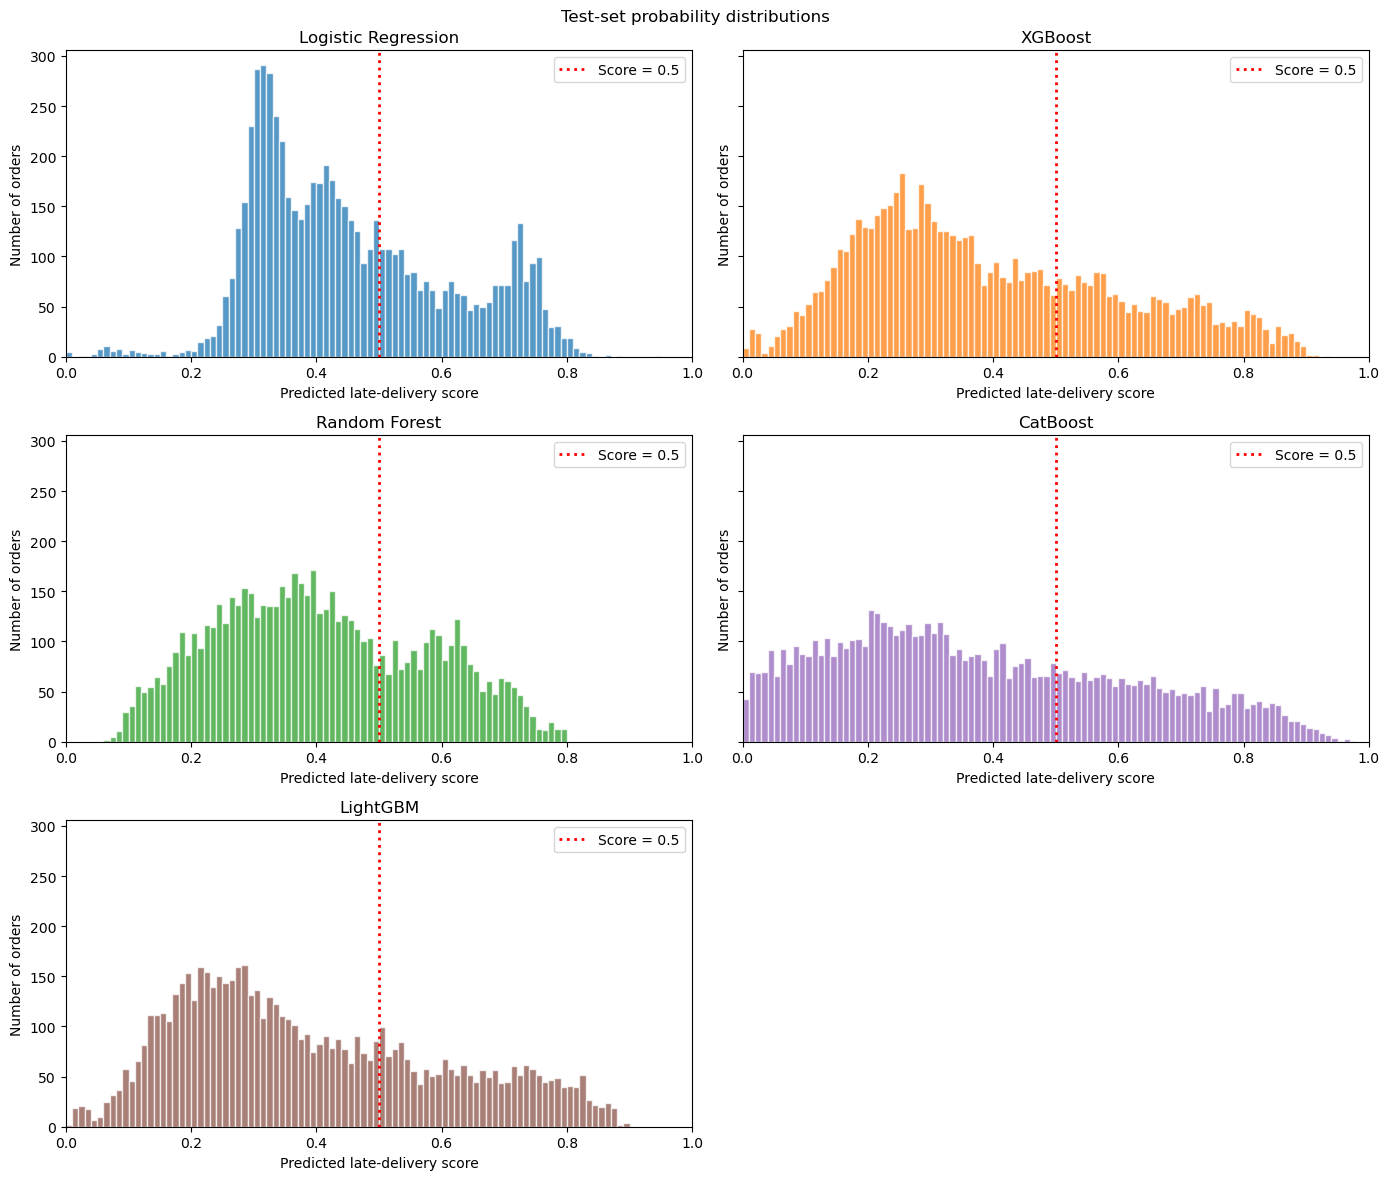

In [154]:
# Use the same bins and axis scales to compare all five models.
fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True, sharey=True)
bins = np.linspace(0, 1, 101)
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:purple', 'tab:brown']

for ax, (name, scores), color in zip(axes.flat, model_scores.items(), colors):
    ax.hist(scores, bins=bins, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(0.5, color='red', linestyle=':', linewidth=2, label='Score = 0.5')
    ax.set_title(name)
    ax.set_xlabel('Predicted late-delivery score')
    ax.set_ylabel('Number of orders')
    ax.set_xlim(0, 1)
    ax.tick_params(labelbottom=True)
    ax.legend()

for ax in list(axes.flat)[len(model_scores):]:
    ax.set_visible(False)

fig.suptitle('Test-set probability distributions')
plt.tight_layout()
plt.show()

# Inference
- Using the trained models, peform inference on a live cohort of newly aprroved orders
- Orders eligibility:
    - These orders are not delivered yet, they are all eligible orders approved on the inference date
- Operation:
    - Model trained on 2nd day of each month such that the inference date is the 1st
    - This model will be used to predict for all days in that month
    - The predictions on these 30/31 days will then be collated to have sufficient data to compute the evaluation metrics and coverage
        - When the predictions for all these days are collated, we need to perform re-ranking of the model scores to achieve the decile splits

In [158]:
def get_month_start_end(run_date: str):
    """Return the first and last dates of run_date's month as YYYY-MM-DD strings."""
    from calendar import monthrange
    from datetime import date

    if not isinstance(run_date, str):
        raise ValueError('run_date must be a YYYY-MM-DD string')
    try:
        run_day = date.fromisoformat(run_date)
    except ValueError as exc:
        raise ValueError('run_date must be a valid date in YYYY-MM-DD format') from exc
    if run_day.isoformat() != run_date:
        raise ValueError('run_date must be a valid date in YYYY-MM-DD format')

    month_start = run_day.replace(day=1)
    month_end = run_day.replace(day=monthrange(run_day.year, run_day.month)[1])
    return month_start.isoformat(), month_end.isoformat()

inference_month_start_date, inference_month_end_date = get_month_start_end(run_date)
print(f'Days to run inference: {inference_month_start_date} to {inference_month_end_date}')

Days to run inference: 2018-06-01 to 2018-06-30


## Perform inference loop
- Loop over the inference days to collect all the predictions and perform evaluation

In [162]:
# Reuse the fitted model and training medians; do not refit on inference data.
daily_prediction_frames = []
late_class_index = list(lgb_pipeline.classes_).index(1)
approval_days = pd.to_datetime(final_df['order_approved_dt']).dt.normalize()
delivery_times = pd.to_datetime(final_df['order_delivered_customer_date'])

for inference_day in pd.date_range(inference_month_start_date, inference_month_end_date, freq='D'):
    daily_run_timestamp = inference_day + pd.Timedelta(days=1, minutes=30)
    # Future deliveries are still undelivered at this historical prediction time.
    eligible = approval_days.eq(inference_day) & (
        delivery_times.isna() | delivery_times.gt(daily_run_timestamp)
    )
    daily_orders = final_df.loc[eligible].copy()
    if daily_orders.empty:
        continue

    daily_features = daily_orders[FEATURE_COLS].copy()
    daily_features[numeric_cols] = (
        daily_features[numeric_cols].astype(float).fillna(numeric_medians)
    )

    daily_predictions = daily_orders[['order_approved_dt', 'order_id']].copy()
    print(f"{inference_day}: {daily_predictions['order_id'].count()} orders")

    daily_predictions['order_approved_dt'] = inference_day
    daily_predictions['predicted_probability'] = lgb_pipeline.predict_proba(
        daily_features
    )[:, late_class_index]
    daily_prediction_frames.append(daily_predictions)

lgb_inference_predictions = (
    pd.concat(daily_prediction_frames, ignore_index=True)
    .sort_values(['order_approved_dt', 'order_id'], ignore_index=True)
    if daily_prediction_frames else pd.DataFrame({
        'order_approved_dt': pd.Series(dtype='datetime64[ns]'),
        'order_id': pd.Series(dtype='object'),
        'predicted_probability': pd.Series(dtype='float64')
    })
)
print(f'LightGBM predictions: {len(lgb_inference_predictions):,} orders across '
      f'{lgb_inference_predictions["order_approved_dt"].nunique()} days.')
display(lgb_inference_predictions)

2018-06-01 00:00:00: 147 orders
2018-06-02 00:00:00: 164 orders
2018-06-03 00:00:00: 156 orders
2018-06-04 00:00:00: 178 orders
2018-06-05 00:00:00: 266 orders
2018-06-06 00:00:00: 218 orders
2018-06-07 00:00:00: 232 orders
2018-06-08 00:00:00: 198 orders
2018-06-09 00:00:00: 197 orders
2018-06-10 00:00:00: 141 orders
2018-06-11 00:00:00: 256 orders
2018-06-12 00:00:00: 291 orders
2018-06-13 00:00:00: 259 orders
2018-06-14 00:00:00: 241 orders
2018-06-15 00:00:00: 188 orders
2018-06-16 00:00:00: 141 orders
2018-06-17 00:00:00: 135 orders
2018-06-18 00:00:00: 212 orders
2018-06-19 00:00:00: 285 orders
2018-06-20 00:00:00: 212 orders
2018-06-21 00:00:00: 213 orders
2018-06-22 00:00:00: 170 orders
2018-06-23 00:00:00: 194 orders
2018-06-24 00:00:00: 167 orders
2018-06-25 00:00:00: 189 orders
2018-06-26 00:00:00: 283 orders
2018-06-27 00:00:00: 216 orders
2018-06-28 00:00:00: 253 orders
2018-06-29 00:00:00: 195 orders
2018-06-30 00:00:00: 145 orders
LightGBM predictions: 6,142 orders acros

,order_approved_dt,order_id,predicted_probability
0,2018-06-01,00c763284c0056eed753352f5559ff0a,0.21
1,2018-06-01,022d4b171a04520ca2113a48b6b61380,0.24
2,2018-06-01,025a548c7e6d70e6b6cf600a112b0d9c,0.55
3,2018-06-01,038b8c914a94247880b6a34413e74a34,0.20
4,2018-06-01,05bdb94211a1ae1e3734545262f50da3,0.18
...,...,...,...
6137,2018-06-30,f41726f3a7dc9654767a9c5f80089ddd,0.20
6138,2018-06-30,f4ce5abb3bd4aac9e9c5f5685604cbcb,0.45
6139,2018-06-30,f7943f103569d2bb8a79fe584fcd07e5,0.16
6140,2018-06-30,f7dcd88b218022d33734106bf56e3165,0.41


### Attach actual and predicted labels

Predicted labels use a 0.5 threshold. Actual labels use valid recorded delivery outcomes for retrospective evaluation only. Missing or invalid outcomes remain unknown, rather than being labelled on time.

In [163]:
PREDICTION_THRESHOLD = 0.5
outcomes = orders[['order_id', 'order_approved_at', 'order_delivered_customer_date',
                   'order_estimated_delivery_date']].drop_duplicates('order_id').copy()
approved_at = pd.to_datetime(outcomes['order_approved_at'])
delivered_at = pd.to_datetime(outcomes['order_delivered_customer_date'])
estimated_date = pd.to_datetime(outcomes['order_estimated_delivery_date']).dt.normalize()
valid_outcome = (approved_at.notna() & delivered_at.notna() & estimated_date.notna()
                 & delivered_at.ge(approved_at))
outcomes['actual_label'] = pd.Series(pd.NA, index=outcomes.index, dtype='Int64')
outcomes.loc[valid_outcome, 'actual_label'] = (
    delivered_at.loc[valid_outcome].dt.normalize() > estimated_date.loc[valid_outcome]
).astype(int)
# Map by order ID so rerunning does not duplicate rows or columns.
lgb_inference_predictions['actual_label'] = (
    lgb_inference_predictions['order_id'].map(outcomes.set_index('order_id')['actual_label'])
    .astype('Int64')
)
lgb_inference_predictions['predicted_label'] = (
    lgb_inference_predictions['predicted_probability'] >= PREDICTION_THRESHOLD
).astype(int)
print(f"Known actual labels: {lgb_inference_predictions['actual_label'].notna().sum():,}"
      f"/{len(lgb_inference_predictions):,}")
display(lgb_inference_predictions)

Known actual labels: 6,094/6,142


,order_approved_dt,order_id,predicted_probability,actual_label,predicted_label
0,2018-06-01,00c763284c0056eed753352f5559ff0a,0.21,0,0
1,2018-06-01,022d4b171a04520ca2113a48b6b61380,0.24,0,0
2,2018-06-01,025a548c7e6d70e6b6cf600a112b0d9c,0.55,0,1
3,2018-06-01,038b8c914a94247880b6a34413e74a34,0.20,0,0
4,2018-06-01,05bdb94211a1ae1e3734545262f50da3,0.18,0,0
...,...,...,...,...,...
6137,2018-06-30,f41726f3a7dc9654767a9c5f80089ddd,0.20,0,0
6138,2018-06-30,f4ce5abb3bd4aac9e9c5f5685604cbcb,0.45,0,0
6139,2018-06-30,f7943f103569d2bb8a79fe584fcd07e5,0.16,0,0
6140,2018-06-30,f7dcd88b218022d33734106bf56e3165,0.41,0,0


### Evaluate monthly predictions

Calculate accuracy, precision, recall and F1 for orders with known actual labels, treating late delivery (1) as positive. Unknown outcomes are excluded, so metrics describe the observed-outcome subset. Undefined precision/recall/F1 return zero; an empty evaluation set returns missing metrics.

In [165]:
lgb_evaluation_rows = lgb_inference_predictions.dropna(subset=['actual_label']).copy()
if lgb_evaluation_rows.empty:
    metric_values = dict.fromkeys(['accuracy', 'precision', 'recall', 'f1'], np.nan)
else:
    actual = lgb_evaluation_rows['actual_label'].astype(int)
    predicted = lgb_evaluation_rows['predicted_label']
    metric_values = {
        'accuracy': accuracy_score(actual, predicted),
        'precision': precision_score(actual, predicted, zero_division=0),
        'recall': recall_score(actual, predicted, zero_division=0),
        'f1': f1_score(actual, predicted, zero_division=0)
    }
lgb_inference_metrics = pd.DataFrame([metric_values], index=['LightGBM'])
print(f'Evaluated {len(lgb_evaluation_rows):,} orders; '
      f'excluded {len(lgb_inference_predictions) - len(lgb_evaluation_rows):,} unknown outcomes.')
display(lgb_inference_metrics.style.format('{:.2%}', na_rep='N/A'))

Evaluated 6,094 orders; excluded 48 unknown outcomes.


,accuracy,precision,recall,f1
LightGBM,90.71%,3.39%,25.35%,5.98%


### Coverage by ranked probability deciles

Rank the whole month by predicted_probability descending, breaking ties by order_id. Decile 1 has the highest probabilities. Ten groups differ by at most one row; fewer than ten orders leave empty groups. Unknown outcomes remain in the ranking and are counted separately. Late rates use known labels only. Coverage is the cumulative proportion of all observed late orders captured; it is undefined when no observed late orders exist.

In [166]:
lgb_ranked_predictions = lgb_inference_predictions.sort_values(
    ['predicted_probability', 'order_id'], ascending=[False, True], kind='stable'
).reset_index(drop=True).copy()
row_count = len(lgb_ranked_predictions)
base_size, extra_rows = divmod(row_count, 10)
decile_sizes = [base_size + (i < extra_rows) for i in range(10)]
lgb_ranked_predictions['probability_rank'] = np.arange(1, row_count + 1)
lgb_ranked_predictions['decile'] = np.repeat(np.arange(1, 11), decile_sizes)
lgb_inference_coverage = (
    lgb_ranked_predictions.groupby('decile').agg(
        number_of_orders=('order_id', 'size'),
        known_labels=('actual_label', 'count'),
        positive_labels=('actual_label', 'sum')
    ).reindex(range(1, 11), fill_value=0).rename_axis('decile').reset_index()
)
coverage = lgb_inference_coverage
coverage['unknown_labels'] = coverage['number_of_orders'] - coverage['known_labels']
coverage['cumulative_orders'] = coverage['number_of_orders'].cumsum()
coverage['cumulative_known_labels'] = coverage['known_labels'].cumsum()
coverage['cumulative_positive_labels'] = coverage['positive_labels'].cumsum()
coverage['late_delivery_rate'] = (
    coverage['positive_labels'] / coverage['known_labels'].replace(0, np.nan)
)
coverage['cumulative_late_delivery_rate'] = (
    coverage['cumulative_positive_labels']
    / coverage['cumulative_known_labels'].replace(0, np.nan)
)
total_positive_labels = coverage['positive_labels'].sum()
coverage['coverage'] = (
    coverage['cumulative_positive_labels'] / total_positive_labels
    if total_positive_labels > 0 else np.nan
)
display(lgb_inference_coverage.style.format({
    'late_delivery_rate': '{:.2%}',
    'cumulative_late_delivery_rate': '{:.2%}',
    'coverage': '{:.2%}'
}, na_rep='N/A'))

,decile,number_of_orders,known_labels,positive_labels,unknown_labels,cumulative_orders,cumulative_known_labels,cumulative_positive_labels,late_delivery_rate,cumulative_late_delivery_rate,coverage
0,1,615,602,18,13,615,602,18,2.99%,2.99%,25.35%
1,2,615,607,14,8,1230,1209,32,2.31%,2.65%,45.07%
2,3,614,612,9,2,1844,1821,41,1.47%,2.25%,57.75%
3,4,614,612,5,2,2458,2433,46,0.82%,1.89%,64.79%
4,5,614,612,9,2,3072,3045,55,1.47%,1.81%,77.46%
5,6,614,608,1,6,3686,3653,56,0.16%,1.53%,78.87%
6,7,614,613,5,1,4300,4266,61,0.82%,1.43%,85.92%
7,8,614,607,5,7,4914,4873,66,0.82%,1.35%,92.96%
8,9,614,607,3,7,5528,5480,69,0.49%,1.26%,97.18%
9,10,614,614,2,0,6142,6094,71,0.33%,1.17%,100.00%


# Archive

In [28]:
def get_train_test_months(input_month: str, n_train_months: int = 6):
    """Return consecutive months before the input month, oldest first."""
    if isinstance(n_train_months, bool) or not isinstance(n_train_months, int) or n_train_months < 1:
        raise ValueError('n_train_months must be a positive integer')

    return pd.period_range(
        end=pd.Period(input_month, freq='M') - 2,
        periods=n_train_months,
        freq='M',
    ).astype(str).tolist()

In [29]:
inference_month = '2018-07'
train_test_months = get_train_test_months(inference_month)
print(f"Train-test months for the inference month of {inference_month}: {train_test_months}")

Train-test months for the inference month of 2018-07: ['2017-12', '2018-01', '2018-02', '2018-03', '2018-04', '2018-05']


In [30]:
def get_train_test_months(input_month: str, n_train_months: int = 4):
    """Return training months (oldest first) and the preceding test month."""
    import re

    if not isinstance(input_month, str) or not re.fullmatch(r'[0-9]{4}-(0[1-9]|1[0-2])', input_month):
        raise ValueError('input_month must be a string in YYYY-MM format')
    if isinstance(n_train_months, bool) or not isinstance(n_train_months, int) or n_train_months < 1:
        raise ValueError('n_train_months must be a positive integer')

    test_period = pd.Period(input_month, freq='M') - 1
    train_months = [
        str(test_period - offset)
        for offset in range(n_train_months, 0, -1)
    ]
    test_month = str(test_period)
    return train_months, test_month

train_months, test_month = get_train_test_months('2018-07')
print(f"Train months: {train_months}")
print(f"Test months: {test_month}")

Train months: ['2018-02', '2018-03', '2018-04', '2018-05']
Test months: 2018-06
